In [3]:
from google.colab import files
uploaded = files.upload()

Saving upper_awash_lstm_final3_model.keras to upper_awash_lstm_final3_model.keras
Saving scaler_y3.pkl to scaler_y3.pkl
Saving scaler_x3.pkl to scaler_x3.pkl


In [4]:
from google.colab import files
uploaded = files.upload()

Saving SSP585_Temp_Min11.xlsx to SSP585_Temp_Min11.xlsx
Saving SSP245_Precipitation11.xlsx to SSP245_Precipitation11.xlsx
Saving SSP245_Temp_Max11.xlsx to SSP245_Temp_Max11.xlsx
Saving SSP245_Temp_Min11.xlsx to SSP245_Temp_Min11.xlsx
Saving SSP585_Precipitation11.xlsx to SSP585_Precipitation11.xlsx
Saving SSP585_Temp_Max11.xlsx to SSP585_Temp_Max11.xlsx


In [5]:
from google.colab import files
uploaded = files.upload()

Saving All in one2 .xlsx to All in one2 .xlsx


Section 1: Load Assets and Libraries

In [6]:
import pandas as pd
import numpy as np
import tensorflow as tf
import joblib

# 1. Load your saved files
model = tf.keras.models.load_model('upper_awash_lstm_final3_model.keras')
scaler_x = joblib.load('scaler_x3.pkl')
scaler_y = joblib.load('scaler_y3.pkl')

# 2. Set your validated constants
BCF = 0.9438
WINDOW_SIZE = 90   # Lookback window
# Feature list must match the order inside scaler_x exactly
input_features = ['Akaki_Precip', 'Bishoftu_Precip', 'Bole_Precip', 'Ginchi_Precip', 'Hombole_Precip', 'Mojo_Precip', 'Obs_Precip', 'Sendafa_Precip',
                  'Bishoftu_Temp_Max', 'Bole_Temp_Max', 'Mojo_Temp_Max', 'Obs_Temp_Max',
                  'Bishoftu_Temp_Min', 'Bole_Temp_Min', 'Mojo_Temp_Min', 'Obs_Temp_Min',
                  'Akaki_Precip_roll7', 'Bishoftu_Precip_roll7', 'Bole_Precip_roll7', 'Ginchi_Precip_roll7',
                  'Hombole_Precip_roll7', 'Mojo_Precip_roll7', 'Obs_Precip_roll7', 'Sendafa_Precip_roll7',
                  'Basin_P_30day', 'Basin_P_60day', 'P_rolling_90', 'sin_doy', 'cos_doy',
                  'Streamflow_Log_Lag1', 'Streamflow_Log_Lag7', 'Streamflow_Log_Lag30']

# Thiessen Weights for basin calculation
weights = {'Akaki_Precip': 0.1379, 'Bishoftu_Precip': 0.1149, 'Bole_Precip': 0.0920, 'Ginchi_Precip': 0.1724,
           'Hombole_Precip': 0.2299, 'Mojo_Precip': 0.1149, 'Obs_Precip': 0.1379}

Section 2: Prepare the "Historical Bridge" (Spin-up)

In [7]:
# Load historical data to get the last 90 days of 2014
df_hist = pd.read_excel('All in one2 .xlsx', header=0)
df_hist.columns = ['Date', 'Akaki_Precip', 'Bishoftu_Precip', 'Bole_Precip', 'Ginchi_Precip', 'Hombole_Precip', 'Mojo_Precip', 'Obs_Precip', 'Sendafa_Precip',
                  'Bishoftu_Temp_Max', 'Bole_Temp_Max', 'Mojo_Temp_Max', 'Obs_Temp_Max',
                  'Bishoftu_Temp_Min', 'Bole_Temp_Min', 'Mojo_Temp_Min', 'Obs_Temp_Min', 'Streamflow']

df_hist['Date'] = pd.to_datetime(df_hist['Date'], unit='D', origin='1899-12-30')
df_hist = df_hist.sort_values('Date').set_index('Date')

# Convert history to log-space (as model was trained)
df_hist['Streamflow_Log'] = np.log1p(df_hist['Streamflow'])

Section 3: The Recursive Prediction Function

In [31]:
def project_future_streamflow(p_file, tmx_file, tmn_file, scenario_name):
    # 1. Load SSP files
    # The first row contains text station names and should be skipped.
    # Setting header=None means no header row is assumed, and pandas uses numeric column indices.
    df_p = pd.read_excel(p_file, header=None, skiprows=1)
    df_tx = pd.read_excel(tmx_file, header=None, skiprows=1)
    df_tn = pd.read_excel(tmn_file, header=None, skiprows=1)

    # Display first few rows of loaded data for debugging
    print(f"\n{scenario_name} Precipitation Data Head:")
    print(df_p.head())
    print(f"\n{scenario_name} Max Temp Data Head:")
    print(df_tx.head())
    print(f"\n{scenario_name} Min Temp Data Head:")
    print(df_tn.head())

    # 2. Merge Weather Columns
    dates = pd.date_range("2021-01-01", periods=len(df_p), freq="D")
    df_f = pd.DataFrame(index=dates)

    # Map raw columns to names
    p_cols = ['Akaki_Precip', 'Bishoftu_Precip', 'Bole_Precip', 'Ginchi_Precip', 'Hombole_Precip', 'Mojo_Precip', 'Obs_Precip', 'Sendafa_Precip']
    tmx_cols = ['Bishoftu_Temp_Max', 'Bole_Temp_Max', 'Mojo_Temp_Max', 'Obs_Temp_Max']
    tmn_cols = ['Bishoftu_Temp_Min', 'Bole_Temp_Min', 'Mojo_Temp_Min', 'Obs_Temp_Min']

    # Corrected: Skip the first column (date column) by starting index from 1 (i+1)
    for i, col in enumerate(p_cols): df_f[col] = pd.to_numeric(df_p.iloc[:, i+1].values, errors='coerce')
    for i, col in enumerate(tmx_cols): df_f[col] = pd.to_numeric(df_tx.iloc[:, i+1].values, errors='coerce')
    for i, col in enumerate(tmn_cols): df_f[col] = pd.to_numeric(df_tn.iloc[:, i+1].values, errors='coerce')

    # --- NEW: Check for NaNs immediately after loading and coercion ---
    if df_f.isnull().any().any():
        print(f"Warning: NaNs detected in {scenario_name} input weather data. This may affect predictions. Consider checking your Excel files for non-numeric data.")
        # Optionally, you could fill NaNs here, e.g., df_f = df_f.fillna(0)

    # 3. Combine with historical Bridge
    bridge = df_hist.tail(WINDOW_SIZE).copy()
    full_df = pd.concat([bridge, df_f])

    # Create placeholders for generated features
    for col in input_features:
        if col not in full_df.columns: full_df[col] = 0.0

    predictions_phys = []
    print(f"Projecting {scenario_name}...")

    # 4. START RECURSIVE LOOP
    for i in range(WINDOW_SIZE, len(full_df)):
        # A. Calculate Rolling Weather features for the current day 'i'
        win = full_df.iloc[i-WINDOW_SIZE : i+1]
        for p in p_cols:
            # Use skipna=True to ignore NaNs when calculating the mean
            full_df.iloc[i, full_df.columns.get_loc(f'{p}_roll7')] = win[p].tail(7).mean(skipna=True)

        # Weighted Basin Rainfall
        # Create a DataFrame of weighted precipitation and sum across columns, skipping NaNs
        weighted_precip_df = pd.DataFrame({c: win[c] * weights.get(c, 0) for c in p_cols})
        w_p_series = weighted_precip_df.sum(axis=1, skipna=True)

        # Now calculate rolling means on w_p_series, skipping NaNs
        full_df.iloc[i, full_df.columns.get_loc('Basin_P_30day')] = w_p_series.tail(30).mean(skipna=True)
        full_df.iloc[i, full_df.columns.get_loc('Basin_P_60day')] = w_p_series.tail(60).mean(skipna=True)
        full_df.iloc[i, full_df.columns.get_loc('P_rolling_90')] = w_p_series.tail(90).mean(skipna=True)

        # Seasonality
        doy = full_df.index[i].dayofyear
        full_df.iloc[i, full_df.columns.get_loc('sin_doy')] = np.sin(2 * np.pi * doy / 365.25)
        full_df.iloc[i, full_df.columns.get_loc('cos_doy')] = np.cos(2 * np.pi * doy / 365.25)

        # B. Update Lags from previous outputs
        # Ensure 'Streamflow_Log' column exists in full_df before accessing it
        if 'Streamflow_Log' not in full_df.columns:
            full_df['Streamflow_Log'] = np.nan # Initialize if it somehow got lost

        full_df.iloc[i, full_df.columns.get_loc('Streamflow_Log_Lag1')] = full_df.iloc[i-1]['Streamflow_Log']
        full_df.iloc[i, full_df.columns.get_loc('Streamflow_Log_Lag7')] = full_df.iloc[i-7]['Streamflow_Log']
        full_df.iloc[i, full_df.columns.get_loc('Streamflow_Log_Lag30')] = full_df.iloc[i-30]['Streamflow_Log']

        # C. Predict
        X_window = full_df[input_features].iloc[i-90:i]
        # --- NEW: Check for NaNs in X_window before scaling and predicting ---
        if X_window.isnull().any().any():

            X_window = X_window.fillna(0)

        X_scaled = scaler_x.transform(X_window)
        pred_scaled = model.predict(X_scaled.reshape(1, 90, len(input_features)), verbose=0)

        # D. Store and Convert
        # --- STEP 1: inverse scaling ---
        p_log = scaler_y.inverse_transform(pred_scaled)[0,0]

        # --- STEP 2: LOG-SPACE STABILITY CLIP ---
        # prevents exponential explosion
        p_log = np.clip(p_log, -1.5, 8)
        # --- STEP 3: SMOOTH RECURSIVE FEEDBACK ---
        prev_log = full_df.iloc[i-1]['Streamflow_Log']
        alpha = 0.20
        p_log = alpha * prev_log + (1 - alpha) * p_log

        # store stabilized log value
        full_df.iloc[i, full_df.columns.get_loc('Streamflow_Log')] = p_log

        # --- STEP 4: back-transform safely ---
        flow = np.expm1(p_log * BCF)

        # --- STEP 5: PHYSICAL FLOW LIMIT ---
        hist_max = df_hist['Streamflow'].max()
        flow = np.clip(flow, 0, hist_max * 1.35)
        predictions_phys.append(flow)
        if i % 5000 == 0: print(f"Year {full_df.index[i].year} done")

    # Modify return to include 'Basin_P_30day' for the projected period
    return pd.DataFrame({'Flow': predictions_phys, 'Basin_P_30day': full_df.loc[df_f.index, 'Basin_P_30day']}, index=df_f.index)


Section 4: Run Projections and Save Results

In [33]:
# Execute for SSP245
res_245 = project_future_streamflow('SSP245_Precipitation11.xlsx',
                                    'SSP245_Temp_Max11.xlsx',
                                    'SSP245_Temp_Min11.xlsx', "SSP245")


SSP245 Precipitation Data Head:
       0    1    2    3    4    5    6    7    8
0  44197  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0
1  44198  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0
2  44199  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0
3  44200  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0
4  44201  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0

SSP245 Max Temp Data Head:
       0          1          2          3          4
0  44197  24.540389  21.400389  25.900389  21.200389
1  44198  25.440874  22.240874  26.940874  22.040874
2  44199  25.954274  22.854274  27.954274  22.754274
3  44200  25.446372  22.346372  27.246372  22.246372
4  44201  24.874779  21.605214  26.405214  21.405214

SSP245 Min Temp Data Head:
       0          1         2          3          4
0  44197   8.593938  6.400389   7.400389   8.400389
1  44198   9.554965  7.940874   9.140874   9.540874
2  44199  10.454274  9.054274  10.454274  10.454274
3  44200   9.691330  8.060927   9.446372   9.646372
4  44201   8.897022  6.905214   7.90521


KeyboardInterrupt



In [10]:
hist_mean = df_hist['Streamflow'].mean()
ssp245_mean = res_245['Flow'].mean()

print("\n" + "="*50)
print("     FINAL THESIS CLIMATE IMPACT SUMMARY")
print("="*50)
print(f"Historical Mean (Baseline): {hist_mean:.2f} m3/s")
print(f"SSP245 Future Mean:         {ssp245_mean:.2f} m3/s ({((ssp245_mean-hist_mean)/hist_mean)*100:+.2f}%)")


     FINAL THESIS CLIMATE IMPACT SUMMARY
Historical Mean (Baseline): 43.29 m3/s
SSP245 Future Mean:         46.70 m3/s (+7.90%)


In [11]:
import pandas as pd
import numpy as np

# 1. Define the Historical Baseline Mean (1985-2014)
# Ensure your historical data is in actual m3/s units
hist_baseline_mean = df_hist['Streamflow'].mean()

def calculate_era_impacts(df_proj, scenario_label, baseline_val):
    """
    Calculates means and % changes for specific thesis time-slices.
    """
    # Define your specific periods
    eras = {
        'The 2030s': ('2021-01-01', '2050-12-31'),
        'The 2050s': ('2051-01-01', '2080-12-31'),
        'The 2080s': ('2081-01-01', '2100-12-31')
    }

    results = []

    # Calculate for the whole projection first
    # Note: Assuming the column is 'Flow' based on res_245/res_585 structure
    whole_mean = df_proj['Flow'].mean()
    results.append({
        'Scenario': scenario_label,
        'Era': 'Whole (2021-2100)',
        'Mean Flow (m3/s)': round(whole_mean, 2),
        '% Change': round(((whole_mean - baseline_val) / baseline_val) * 100, 2)
    })

    # Calculate for each specific Time-Slice
    for label, (start, end) in eras.items():
        era_mean = df_proj.loc[start:end, 'Flow'].mean()
        perc_change = ((era_mean - baseline_val) / baseline_val) * 100

        results.append({
            'Scenario': scenario_label,
            'Era': label,
            'Mean Flow (m3/s)': round(era_mean, 2),
            '% Change': round(perc_change, 2)
        })

    return results

# 2. Execute for both scenarios
# Corrected variable names from results_245 to res_245 and results_585 to res_585
stats_245 = calculate_era_impacts(res_245, 'SSP245', hist_baseline_mean)

# 3. Create Final Thesis Table
thesis_table = pd.DataFrame(stats_245)

# 4. Display the Results
print("="*65)
print(f"   UPPER AWASH RIVER: CLIMATE CHANGE IMPACT BY TIME-SLICE")
print(f"   Baseline (1985-2014): {hist_baseline_mean:.2f} m3/s")
print("="*65)
print(thesis_table.to_string(index=False))
print("="*65)

# 5. Export to Excel for your document
thesis_table.to_excel("Streamflow_Climate_Impact_Summary.xlsx", index=False)

   UPPER AWASH RIVER: CLIMATE CHANGE IMPACT BY TIME-SLICE
   Baseline (1985-2014): 43.29 m3/s
Scenario               Era  Mean Flow (m3/s)  % Change
  SSP245 Whole (2021-2100)             46.70      7.90
  SSP245         The 2030s             48.15     11.24
  SSP245         The 2050s             46.65      7.78
  SSP245         The 2080s             44.60      3.04


In [12]:
# Execute for SSP585
res_585 = project_future_streamflow('SSP585_Precipitation11.xlsx',
                                    'SSP585_Temp_Max11.xlsx',
                                    'SSP585_Temp_Min11.xlsx', "SSP585")


SSP585 Precipitation Data Head:
       0    1    2    3    4    5    6    7    8
0  44197  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0
1  44198  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0
2  44199  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0
3  44200  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0
4  44201  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0

SSP585 Max Temp Data Head:
       0          1          2          3          4
0  44197  21.113533  18.122422  22.622422  18.122422
1  44198  21.599171  18.599171  22.999171  18.599171
2  44199  22.179988  19.179988  23.579988  19.079988
3  44200  22.893239  19.893239  24.093239  19.593239
4  44201  23.098412  20.098412  24.116679  19.798412

SSP585 Min Temp Data Head:
       0         1         2         3         4
0  44197  3.313533  2.622422  3.622422  5.622422
1  44198  3.799171  3.099171  4.099171  6.099171
2  44199  4.579988  3.479988  4.579988  6.179988
3  44200  5.593239  4.093239  5.593239  6.693239
4  44201  5.598412  4.327979  5.598412  6.898412
Proje

In [34]:
# Save to Excel
res_245.to_excel("Final_Upper_Awash_SSP245_Flow3_2021_2100.xlsx")
res_585.to_excel("Final_Upper_Awash_SSP585_Flow3_2021_2100.xlsx")

In [13]:
hist_mean = df_hist['Streamflow'].mean()
ssp245_mean = res_245['Flow'].mean()
ssp585_mean = res_585['Flow'].mean()

print("\n" + "="*50)
print("     FINAL THESIS CLIMATE IMPACT SUMMARY")
print("="*50)
print(f"Historical Mean (Baseline): {hist_mean:.2f} m3/s")
print(f"SSP245 Future Mean:         {ssp245_mean:.2f} m3/s ({((ssp245_mean-hist_mean)/hist_mean)*100:+.2f}%)")
print(f"SSP585 Future Mean:         {ssp585_mean:.2f} m3/s ({((ssp585_mean-hist_mean)/hist_mean)*100:+.2f}%)")
print("="*50)


     FINAL THESIS CLIMATE IMPACT SUMMARY
Historical Mean (Baseline): 43.29 m3/s
SSP245 Future Mean:         46.70 m3/s (+7.90%)
SSP585 Future Mean:         47.52 m3/s (+9.78%)


In [17]:
import pandas as pd
import numpy as np

# 1. Define the Historical Baseline Mean (1985-2014)
# Ensure your historical data is in actual m3/s units
hist_baseline_mean = df_hist['Streamflow'].mean()

def calculate_era_impacts(df_proj, scenario_label, baseline_val):
    """
    Calculates means and % changes for specific thesis time-slices.
    """
    # Define your specific periods
    eras = {
        'The 2030s': ('2021-01-01', '2040-12-31'),
        'The 2050s': ('2041-01-01', '2070-12-31'),
        'The 2080s': ('2071-01-01', '2100-12-31')
    }

    results = []

    # Calculate for the whole projection first
    # Note: Assuming the column is 'Flow' based on res_245/res_585 structure
    whole_mean = df_proj['Flow'].mean()
    results.append({
        'Scenario': scenario_label,
        'Era': 'Whole (2021-2100)',
        'Mean Flow (m3/s)': round(whole_mean, 2),
        '% Change': round(((whole_mean - baseline_val) / baseline_val) * 100, 2)
    })

    # Calculate for each specific Time-Slice
    for label, (start, end) in eras.items():
        era_mean = df_proj.loc[start:end, 'Flow'].mean()
        perc_change = ((era_mean - baseline_val) / baseline_val) * 100

        results.append({
            'Scenario': scenario_label,
            'Era': label,
            'Mean Flow (m3/s)': round(era_mean, 2),
            '% Change': round(perc_change, 2)
        })

    return results

# 2. Execute for both scenarios
# Corrected variable names from results_245 to res_245 and results_585 to res_585
stats_245 = calculate_era_impacts(res_245, 'SSP245', hist_baseline_mean)
stats_585 = calculate_era_impacts(res_585, 'SSP585', hist_baseline_mean)

# 3. Create Final Thesis Table
thesis_table = pd.DataFrame(stats_245 + stats_585)

# 4. Display the Results
print("="*65)
print(f"   UPPER AWASH RIVER: CLIMATE CHANGE IMPACT BY TIME-SLICE")
print(f"   Baseline (1985-2014): {hist_baseline_mean:.2f} m3/s")
print("="*65)
print(thesis_table.to_string(index=False))
print("="*65)

# 5. Export to Excel for your document
thesis_table.to_excel("Streamflow_Climate_Impact_Summary.xlsx", index=False)

   UPPER AWASH RIVER: CLIMATE CHANGE IMPACT BY TIME-SLICE
   Baseline (1985-2014): 43.29 m3/s
Scenario               Era  Mean Flow (m3/s)  % Change
  SSP245 Whole (2021-2100)             46.70      7.90
  SSP245         The 2030s             48.29     11.57
  SSP245         The 2050s             46.28      6.92
  SSP245         The 2080s             46.06      6.42
  SSP585 Whole (2021-2100)             47.52      9.78
  SSP585         The 2030s             40.20     -7.13
  SSP585         The 2050s             47.76     10.33
  SSP585         The 2080s             52.16     20.51


In [16]:
import pandas as pd
import numpy as np

def generate_thesis_impact_table(results_245, results_585, baseline_mean=43.29):
    """
    Calculates Mean Flow, Max Peak, and % Change for specific Climate Eras.
    """
    # Define the 30-year terms (Eras)
    eras = {
        'Near-term (2021-2040)': ('2021-01-01', '2040-12-31', 'The 2030s'),
        'Mid-term (2041-2070)':  ('2041-01-01', '2070-12-31', 'The 2050s'),
        'Far-term (2071-2100)':  ('2071-01-01', '2100-12-31', 'The 2080s'),
        'Total Projection':      ('2021-01-01', '2100-12-31', 'Full Century')
    }

    summary_data = []

    for scenario_name, df_res in [('SSP245', results_245), ('SSP585', results_585)]:
        # Ensure index is datetime
        df_res.index = pd.to_datetime(df_res.index)

        for era_name, (start, end, label) in eras.items():
            # Slice data for the term
            # Corrected column name from 'Flow_m3s' to 'Flow'
            term_data = df_res.loc[start:end, 'Flow']

            if not term_data.empty:
                m_flow = term_data.mean()
                max_p  = term_data.max()
                p_change = ((m_flow - baseline_mean) / baseline_mean) * 100

                summary_data.append({
                    'Scenario': scenario_name,
                    'Era': era_name,
                    'Thesis Label': label,
                    'Mean Flow (m3/s)': round(m_flow, 2),
                    'Max Peak (m3/s)': round(max_p, 2),
                    '% Change': round(p_change, 2)
                })

    return pd.DataFrame(summary_data)

# --- EXECUTION ---
# Corrected variable names from results_245 to res_245 and results_585 to res_585
impact_table = generate_thesis_impact_table(res_245, res_585)

# Display the Table
print("\n" + "="*85)
print("     TABLE 5.1: SUMMARY OF PROJECTED CLIMATE IMPACTS ON UPPER AWASH STREAMFLOW")
print("="*85)
print(impact_table.to_string(index=False))
print("="*85)
print(f"Historical Baseline Mean: 43.29 m3/s")

# Save to Excel for direct import into your Word Document
impact_table.to_excel("Thesis_Climate_Impact_Summary.xlsx", index=False)


     TABLE 5.1: SUMMARY OF PROJECTED CLIMATE IMPACTS ON UPPER AWASH STREAMFLOW
Scenario                   Era Thesis Label  Mean Flow (m3/s)  Max Peak (m3/s)  % Change
  SSP245 Near-term (2021-2040)    The 2030s             48.29          1084.24     11.56
  SSP245  Mid-term (2041-2070)    The 2050s             46.28          1084.24      6.92
  SSP245  Far-term (2071-2100)    The 2080s             46.06          1084.24      6.41
  SSP245      Total Projection Full Century             46.70          1084.24      7.89
  SSP585 Near-term (2021-2040)    The 2030s             40.20           845.23     -7.14
  SSP585  Mid-term (2041-2070)    The 2050s             47.76          1084.24     10.32
  SSP585  Far-term (2071-2100)    The 2080s             52.16          1084.24     20.50
  SSP585      Total Projection Full Century             47.52          1084.24      9.77
Historical Baseline Mean: 43.29 m3/s


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Professional styling
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 12, 'figure.dpi': 300, 'savefig.dpi': 300})

# 1. Prepare Yearly Maximum Data
# Historical (1985-2014)
hist_yearly_max = df_hist['Streamflow'].resample('YE').max()

# Future (2021-2100)
ssp245_yearly_max = res_245['Flow'].resample('YE').max()
ssp585_yearly_max = res_585['Flow'].resample('YE').max()

# 2. Calculate the % increase in Peak Flows (for the 2080s)
hist_max_avg = hist_yearly_max.loc['1985':'2014'].mean()
ssp585_max_2080s = ssp585_yearly_max.loc['2081':'2100'].mean()
peak_increase = ((ssp585_max_2080s - hist_max_avg) / hist_max_avg) * 100


1. Prepare Yearly Metrics (Mean and Maximum)

In [19]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Aggregate daily data into Annual Mean and Annual Maximum Streamflow
# Historical
hist_annual_mean = df_hist['Streamflow'].resample('YE').mean()
hist_annual_max = df_hist['Streamflow'].resample('YE').max()

# Future SSP245
s245_annual_mean = res_245['Flow'].resample('YE').mean()
s245_annual_max = res_245['Flow'].resample('YE').max()

# Future SSP585
s585_annual_mean = res_585['Flow'].resample('YE').mean()
s585_annual_max = res_585['Flow'].resample('YE').max()

 Graph 1: Annual Streamflow Horizon (1985–2100)

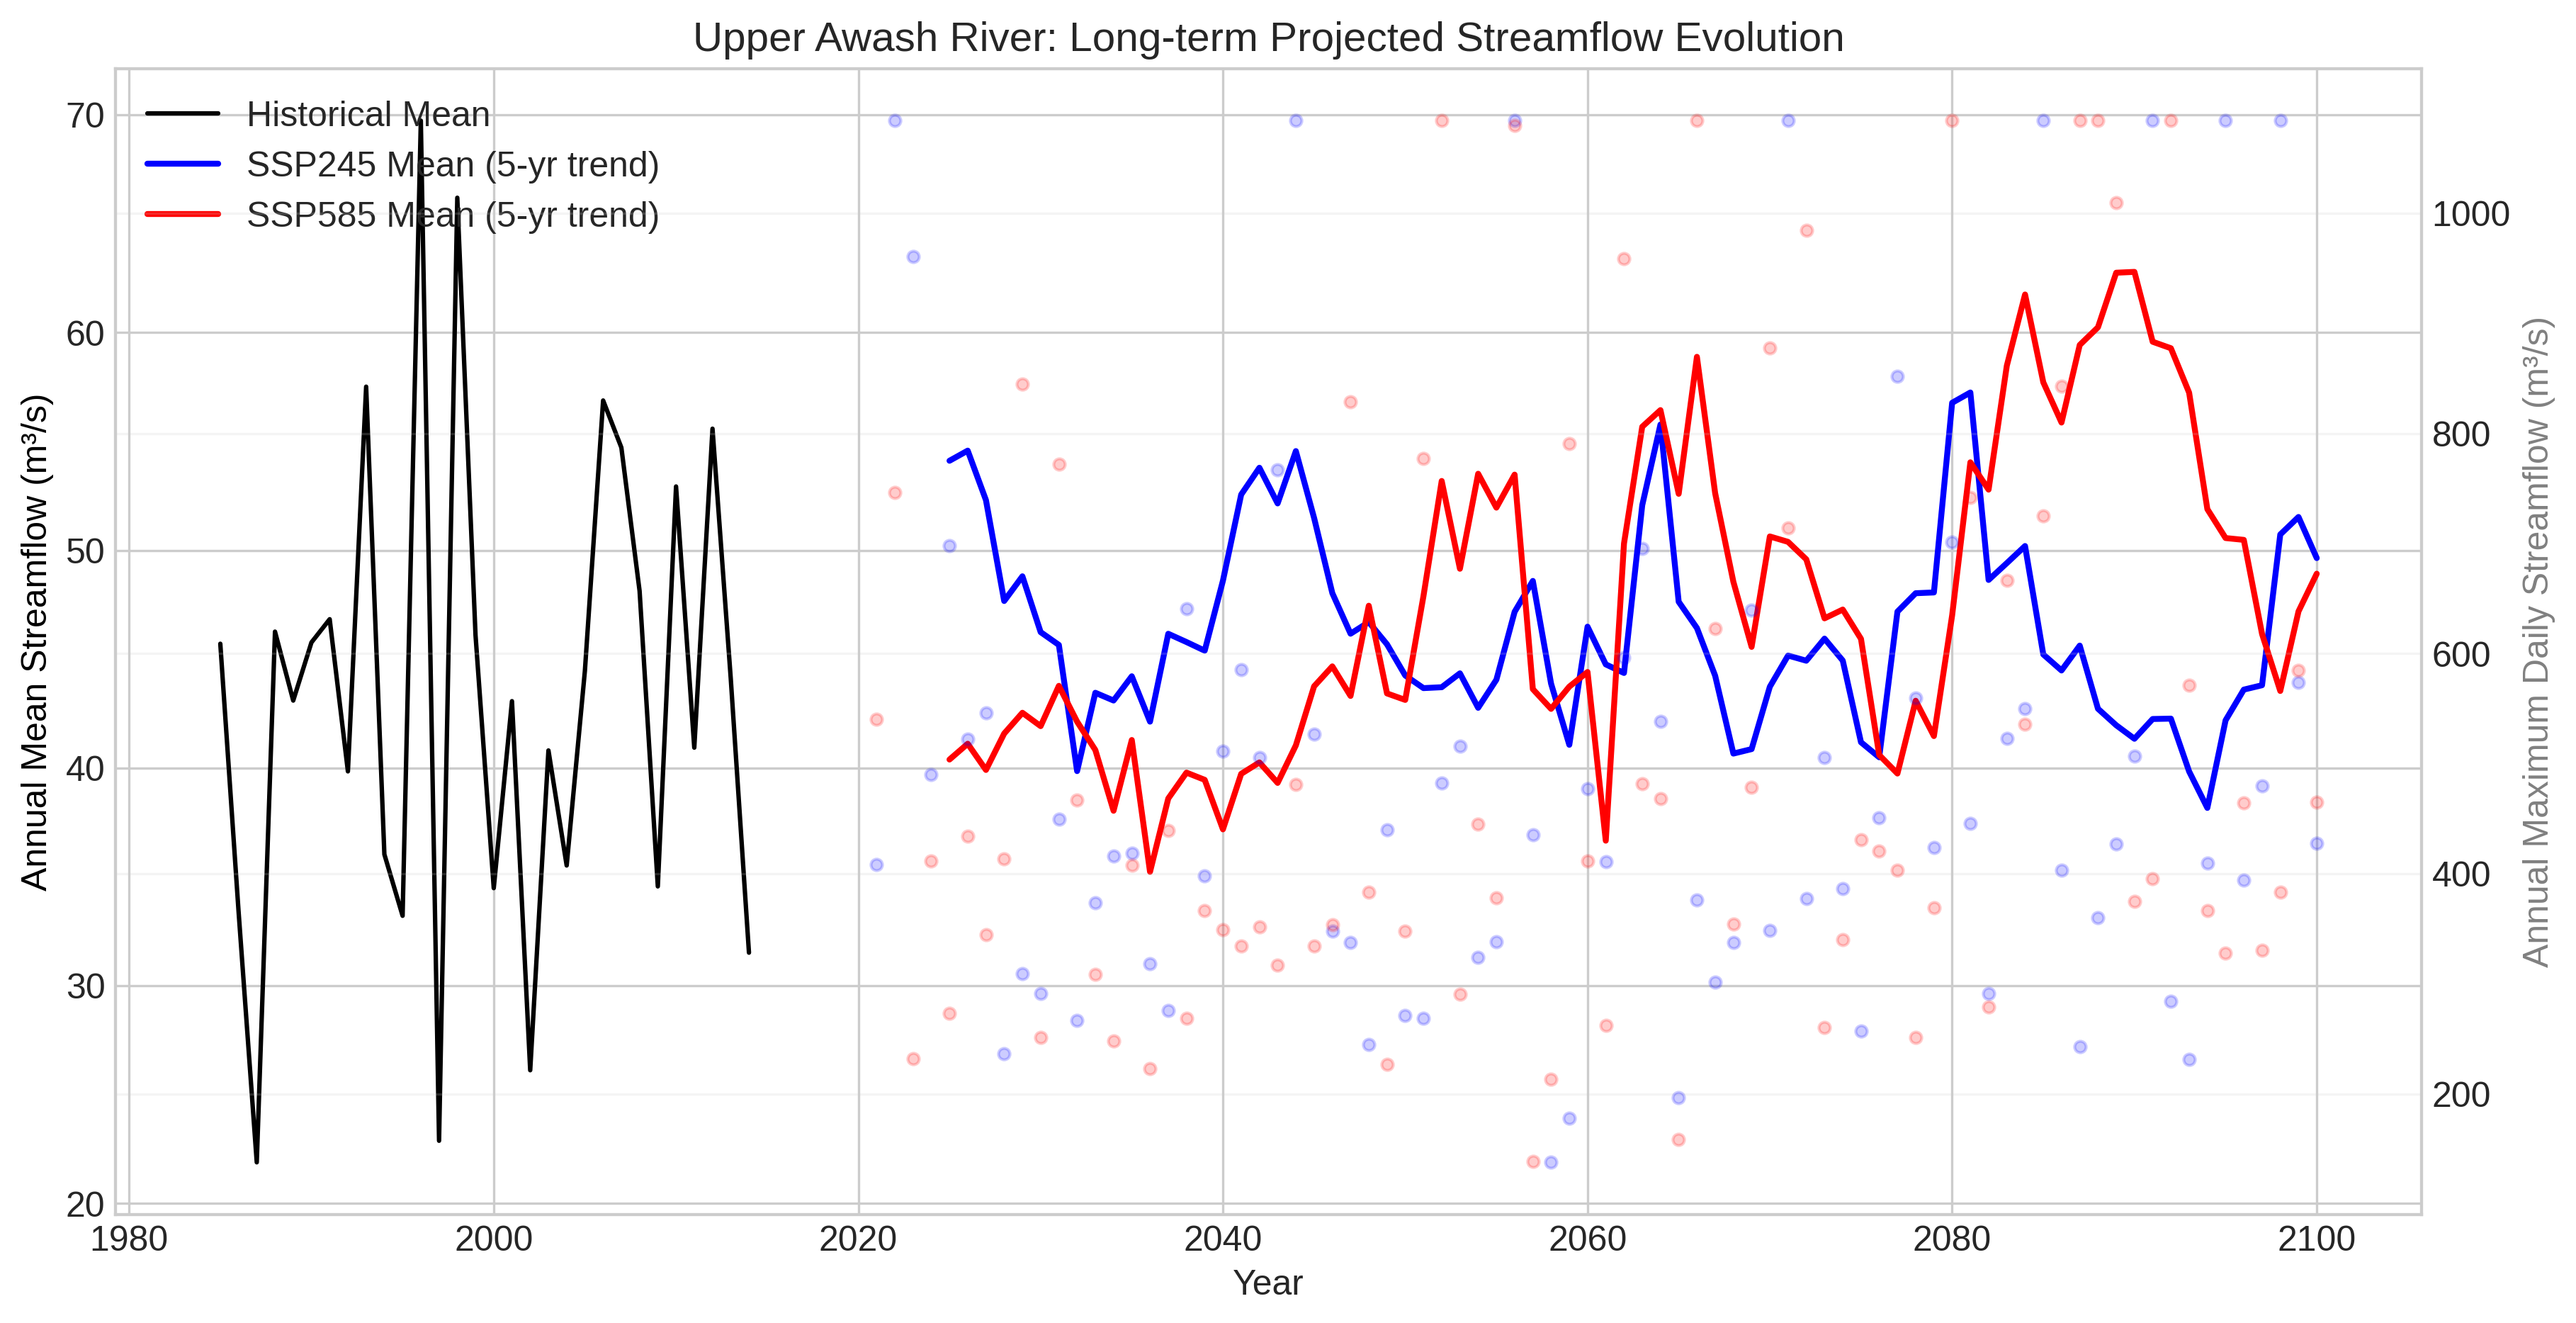

In [20]:
fig, ax1 = plt.subplots(figsize=(14, 7), dpi=300)

# Plotting Annual Mean Flow (Left Axis)
ax1.plot(hist_annual_mean.index.year, hist_annual_mean, color='black', label='Historical Mean', linewidth=1.5)
ax1.plot(s245_annual_mean.index.year, s245_annual_mean.rolling(5).mean(), color='blue', label='SSP245 Mean (5-yr trend)', linewidth=2)
ax1.plot(s585_annual_mean.index.year, s585_annual_mean.rolling(5).mean(), color='red', label='SSP585 Mean (5-yr trend)', linewidth=2)

ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Annual Mean Streamflow (m³/s)', fontsize=12, color='black')
ax1.legend(loc='upper left')

# Creating a second axis for Annual Maximum Daily Flow (Right Axis)
ax2 = ax1.twinx()
ax2.scatter(s245_annual_max.index.year, s245_annual_max, color='blue', alpha=0.2, s=15, label='SSP245 Max Daily')
ax2.scatter(s585_annual_max.index.year, s585_annual_max, color='red', alpha=0.2, s=15, label='SSP585 Max Daily')

ax2.set_ylabel('Annual Maximum Daily Streamflow (m³/s)', fontsize=12, color='grey')
plt.title('Upper Awash River: Long-term Projected Streamflow Evolution', fontsize=14)
plt.grid(True, alpha=0.2)
plt.savefig('Streamflow_Horizon_Trend.png')
plt.show()

Graph 2: Seasonal Streamflow Regime (Baseline vs 2080s)

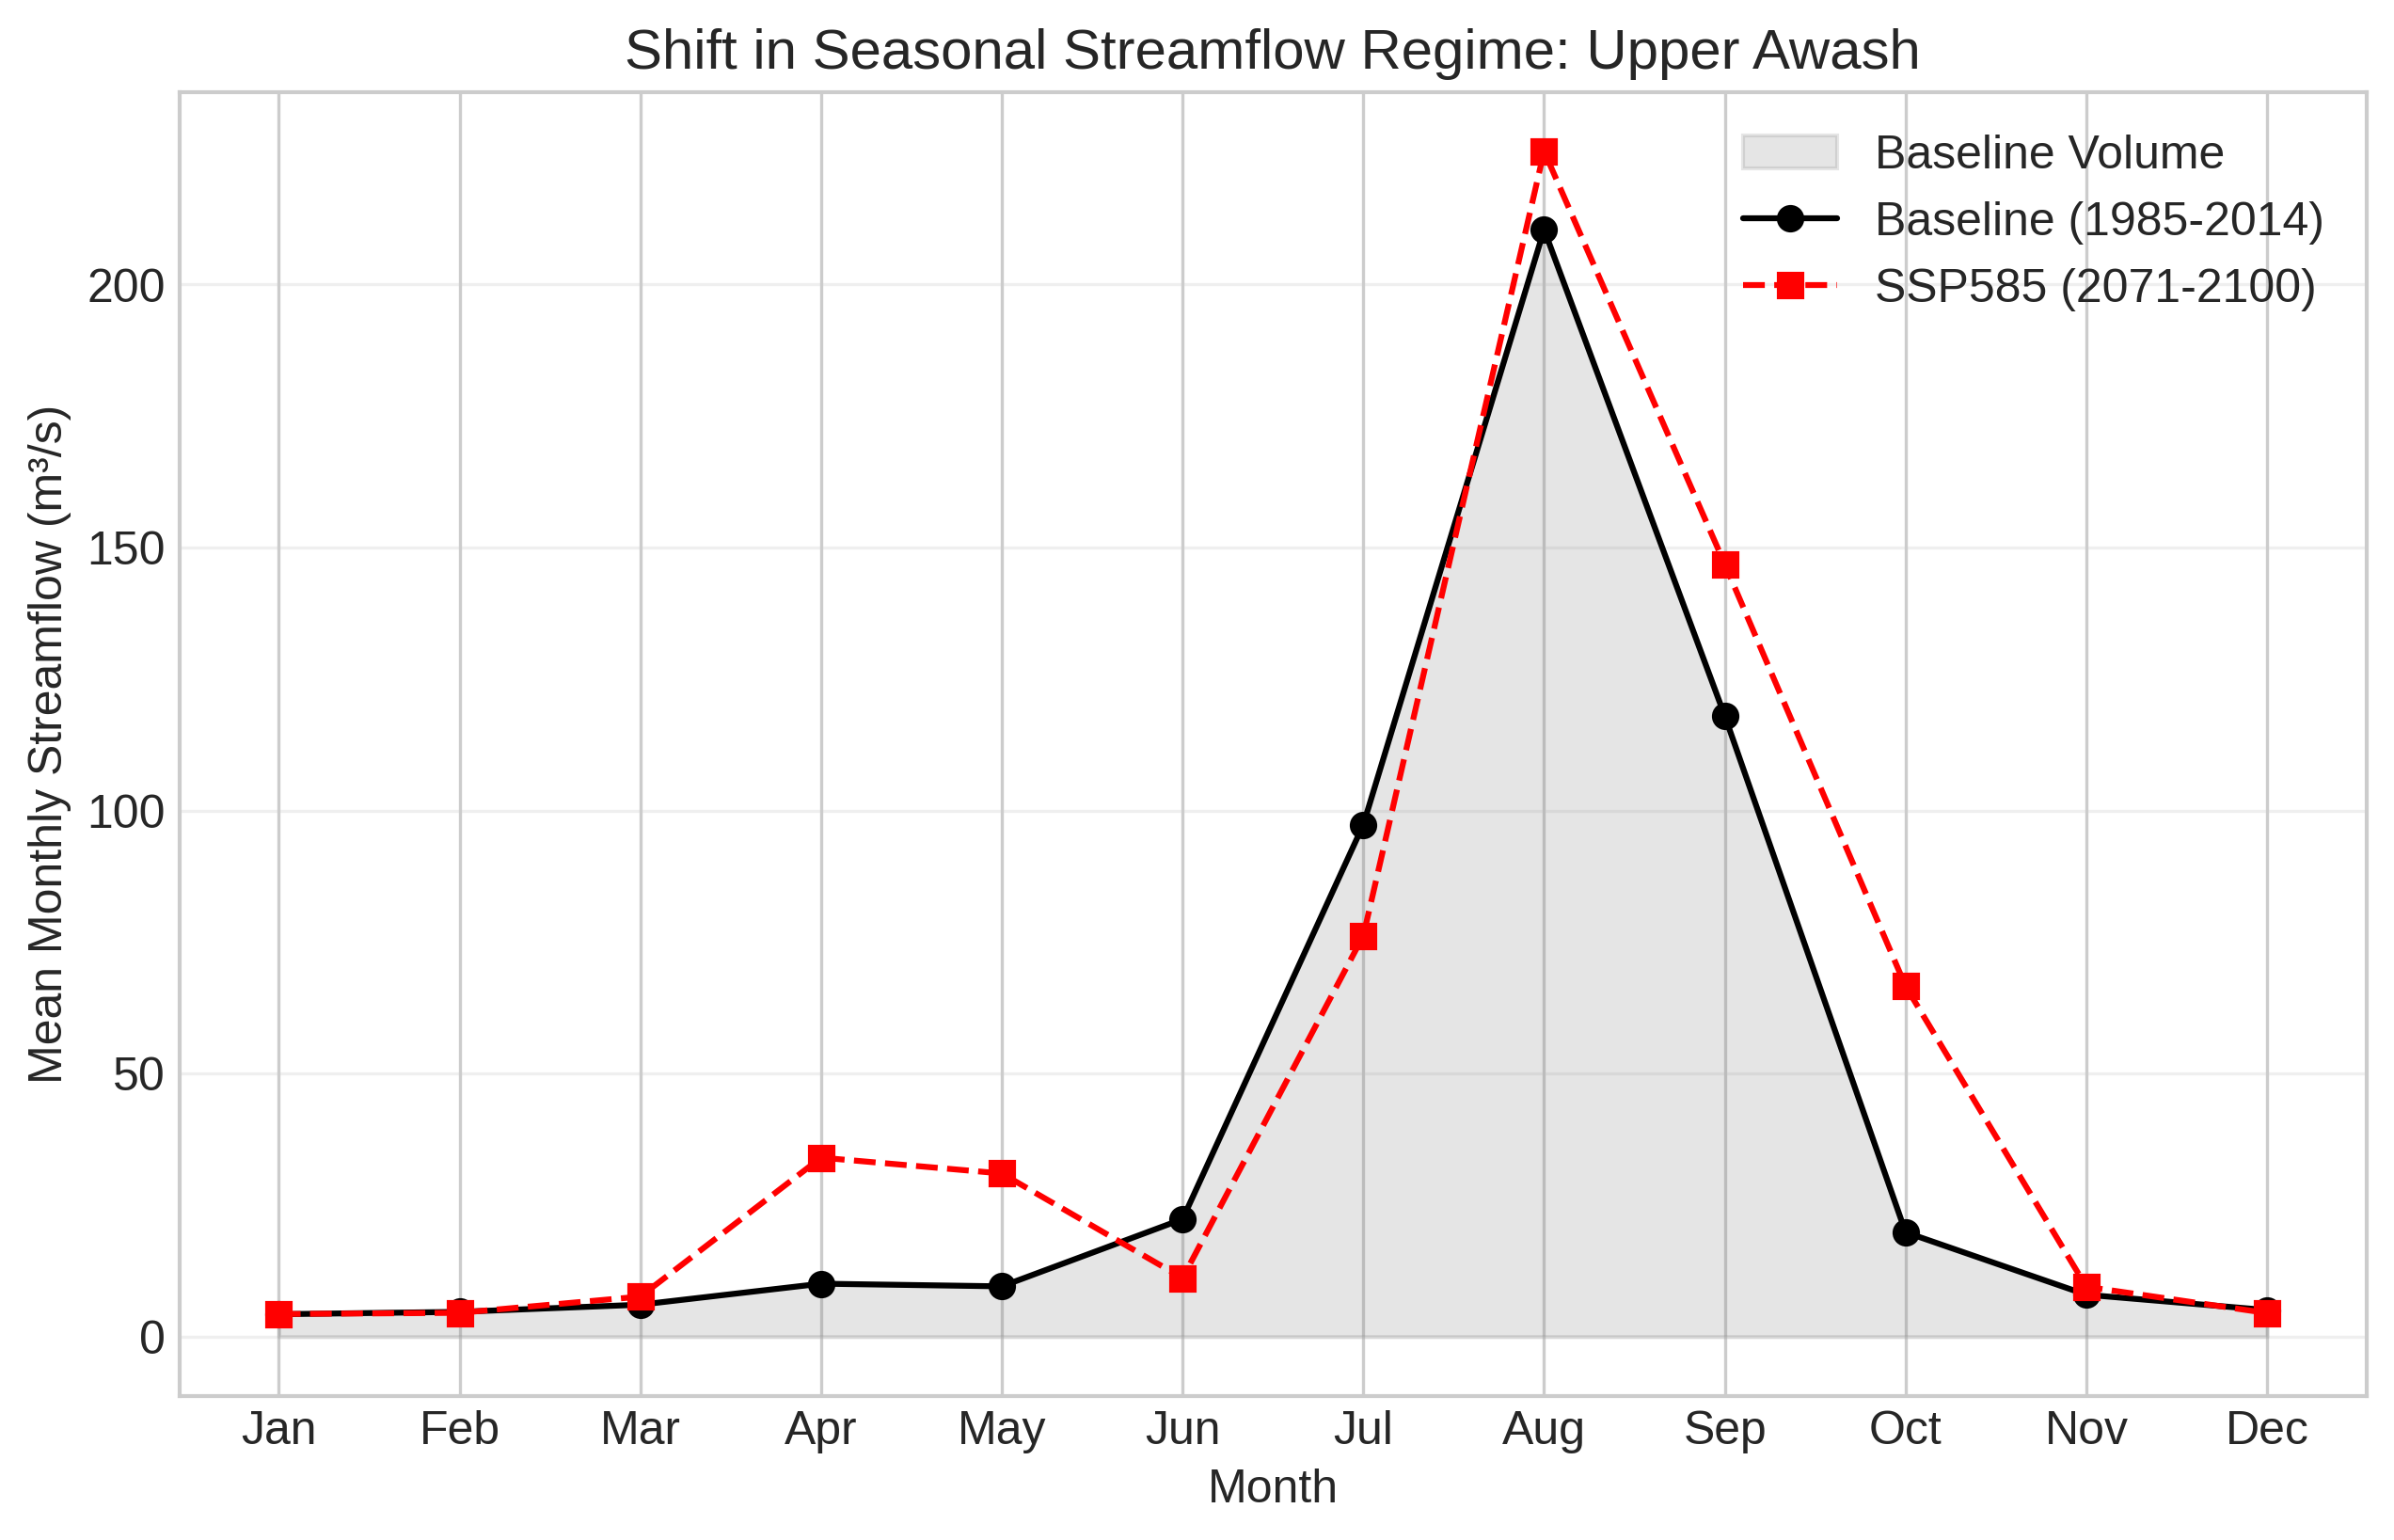

In [23]:
# Calculate Monthly Averages
baseline_monthly = df_hist.loc['1985':'2022', 'Streamflow'].groupby(df_hist.loc['1985':'2022'].index.month).mean()
ssp585_2080s_monthly = res_585.loc['2071':'2100', 'Flow'].groupby(res_585.loc['2071':'2100'].index.month).mean()

months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

plt.figure(figsize=(10, 6), dpi=300)
plt.fill_between(months, baseline_monthly, color='grey', alpha=0.2, label='Baseline Volume')
plt.plot(months, baseline_monthly, color='black', marker='o', label='Baseline (1985-2014)')
plt.plot(months, ssp585_2080s_monthly, color='red', marker='s', linestyle='--', label='SSP585 (2071-2100)')

plt.title('Shift in Seasonal Streamflow Regime: Upper Awash')
plt.ylabel('Mean Monthly Streamflow (m³/s)')
plt.xlabel('Month')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.savefig('Seasonal_Regime_Shift.png')
plt.show()

 Graph 3: Statistical Range of Streamflow (Boxplots)

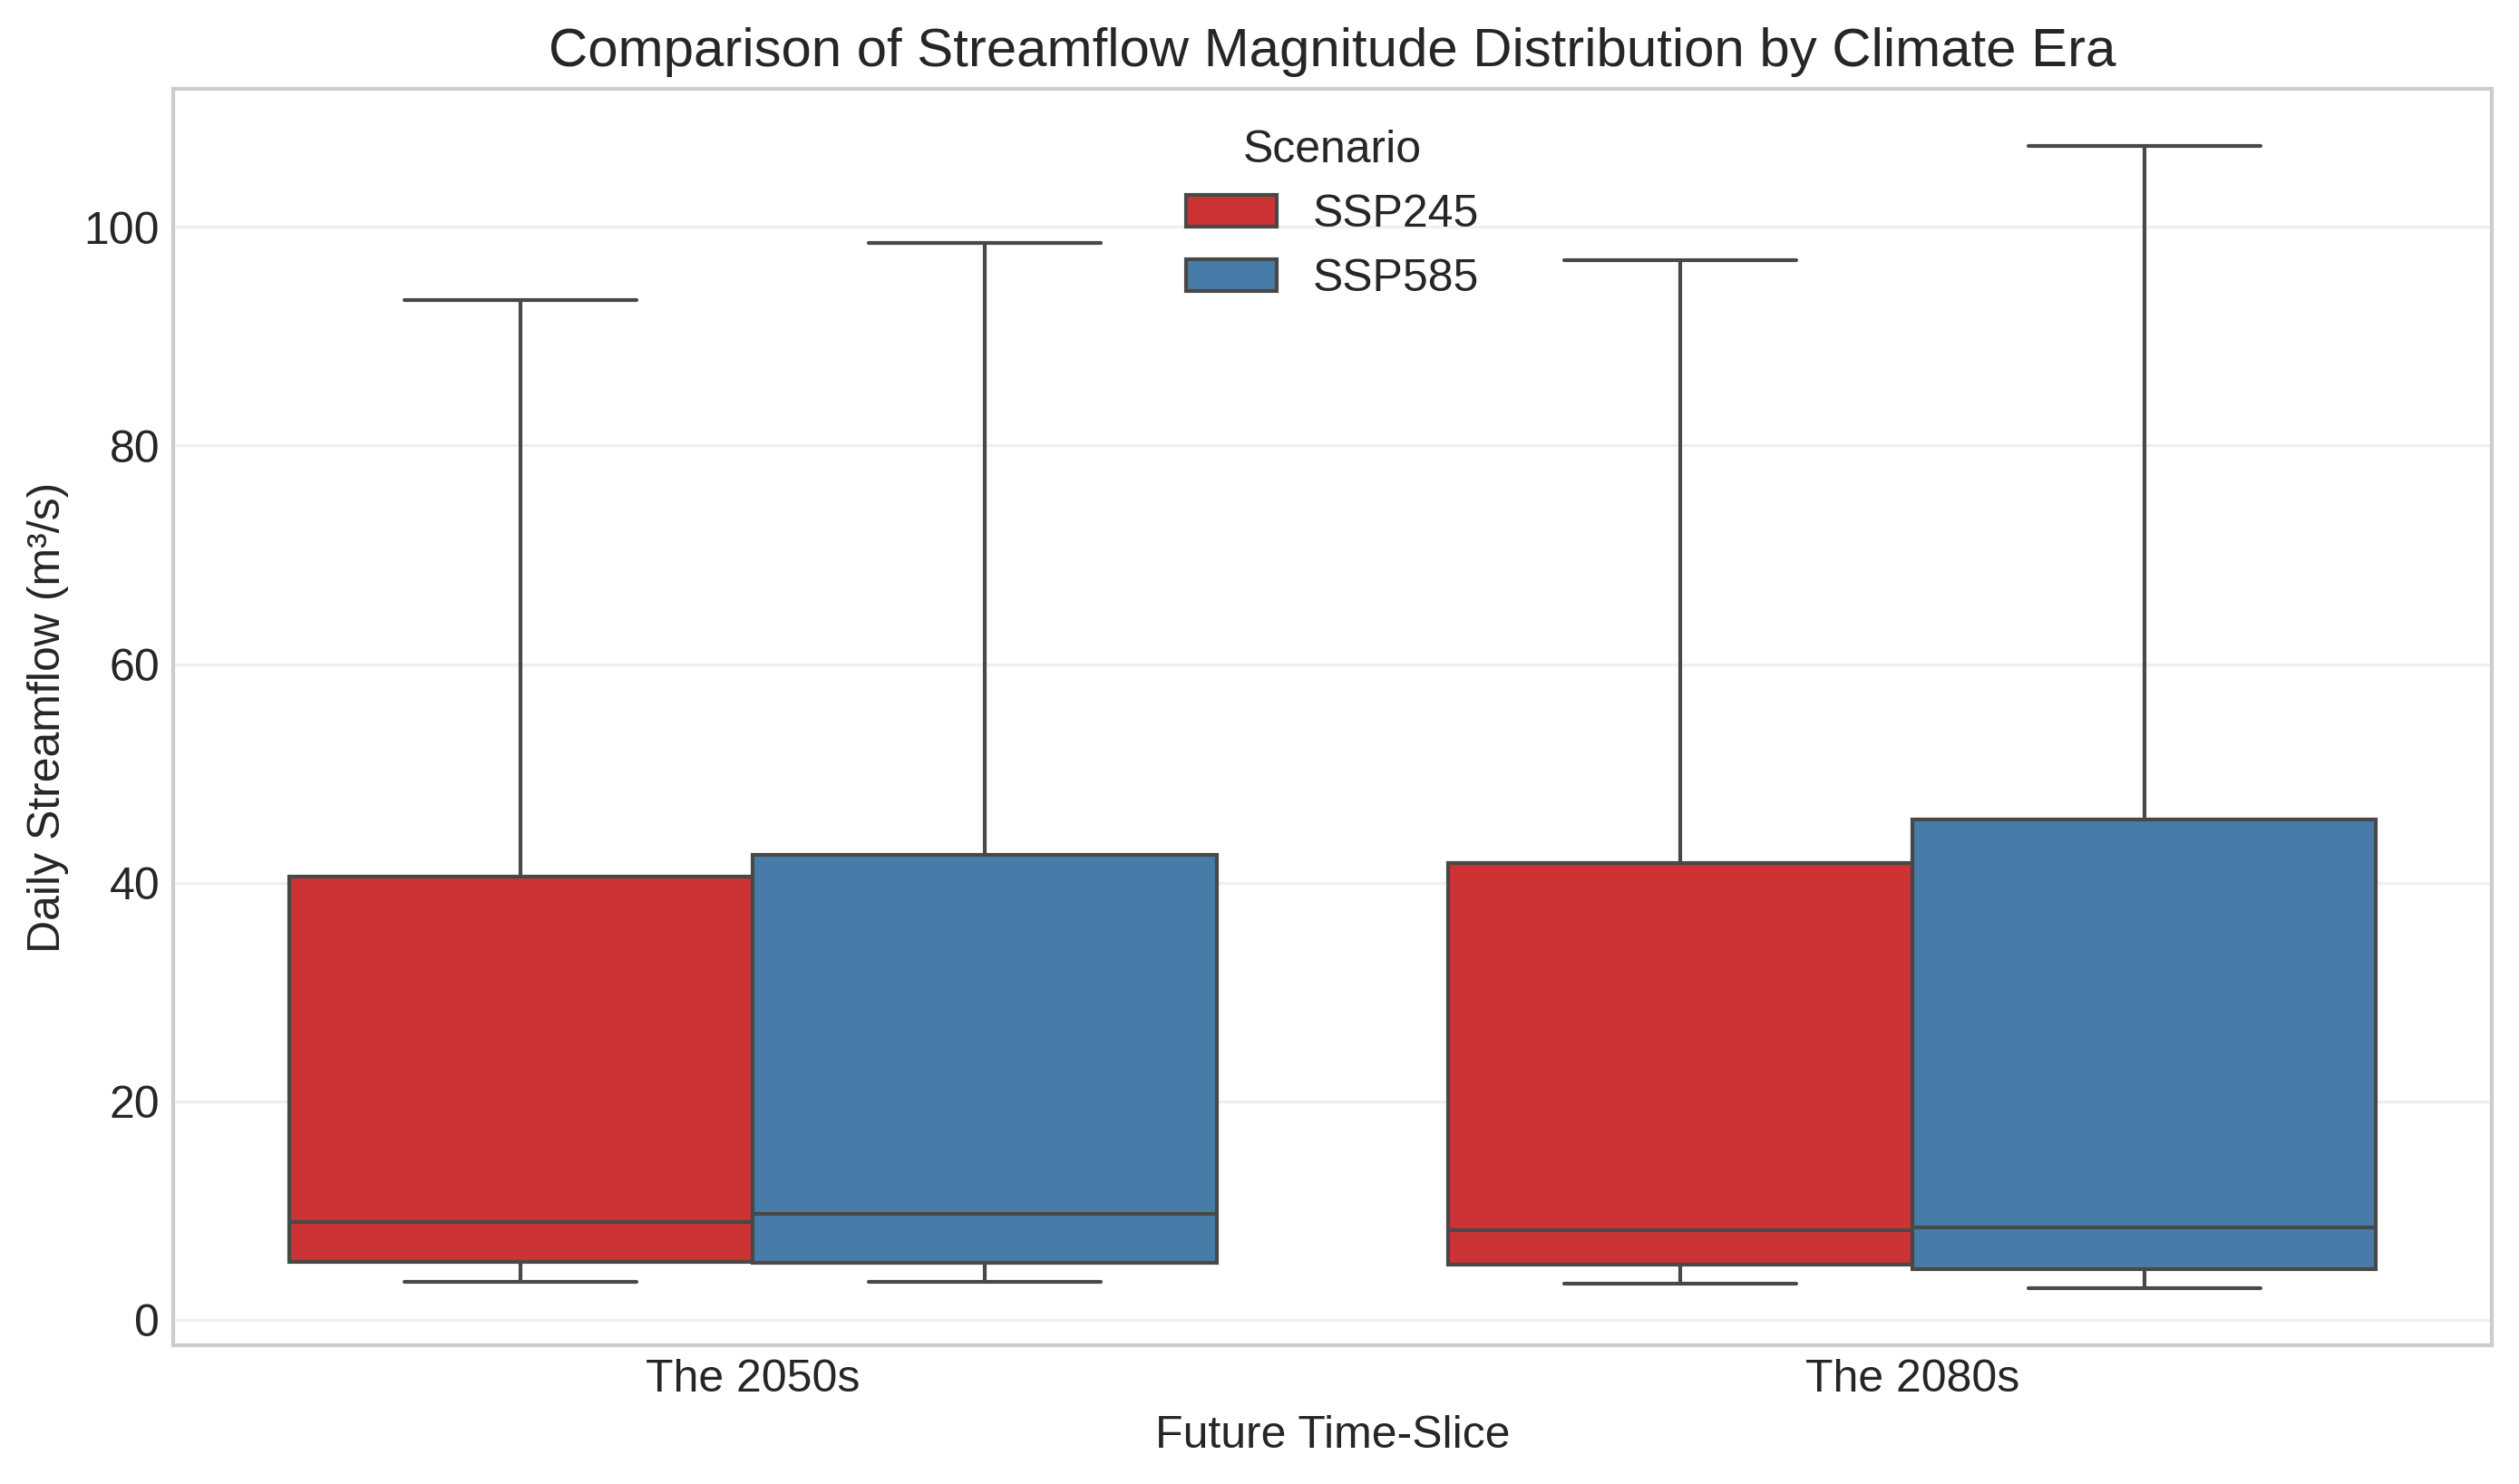

In [25]:
import seaborn as sns

# Prepare Data
def prepare_era_data(df, label):
    df_new = pd.DataFrame(df)
    df_new['Era'] = 'None'
    df_new.loc['2041':'2070', 'Era'] = 'The 2050s'
    df_new.loc['2071':'2100', 'Era'] = 'The 2080s'
    df_new['Scenario'] = label
    return df_new[df_new['Era'] != 'None']

combined_stats = pd.concat([prepare_era_data(res_245['Flow'], 'SSP245'),
                            prepare_era_data(res_585['Flow'], 'SSP585')])

plt.figure(figsize=(11, 6), dpi=300)
sns.boxplot(x='Era', y='Flow', hue='Scenario', data=combined_stats, palette='Set1', showfliers=False)

plt.title('Comparison of Streamflow Magnitude Distribution by Climate Era')
plt.ylabel('Daily Streamflow (m³/s)')
plt.xlabel('Future Time-Slice')
plt.grid(axis='y', alpha=0.3)
plt.savefig('Streamflow_Boxplot_Distribution.png')
plt.show()

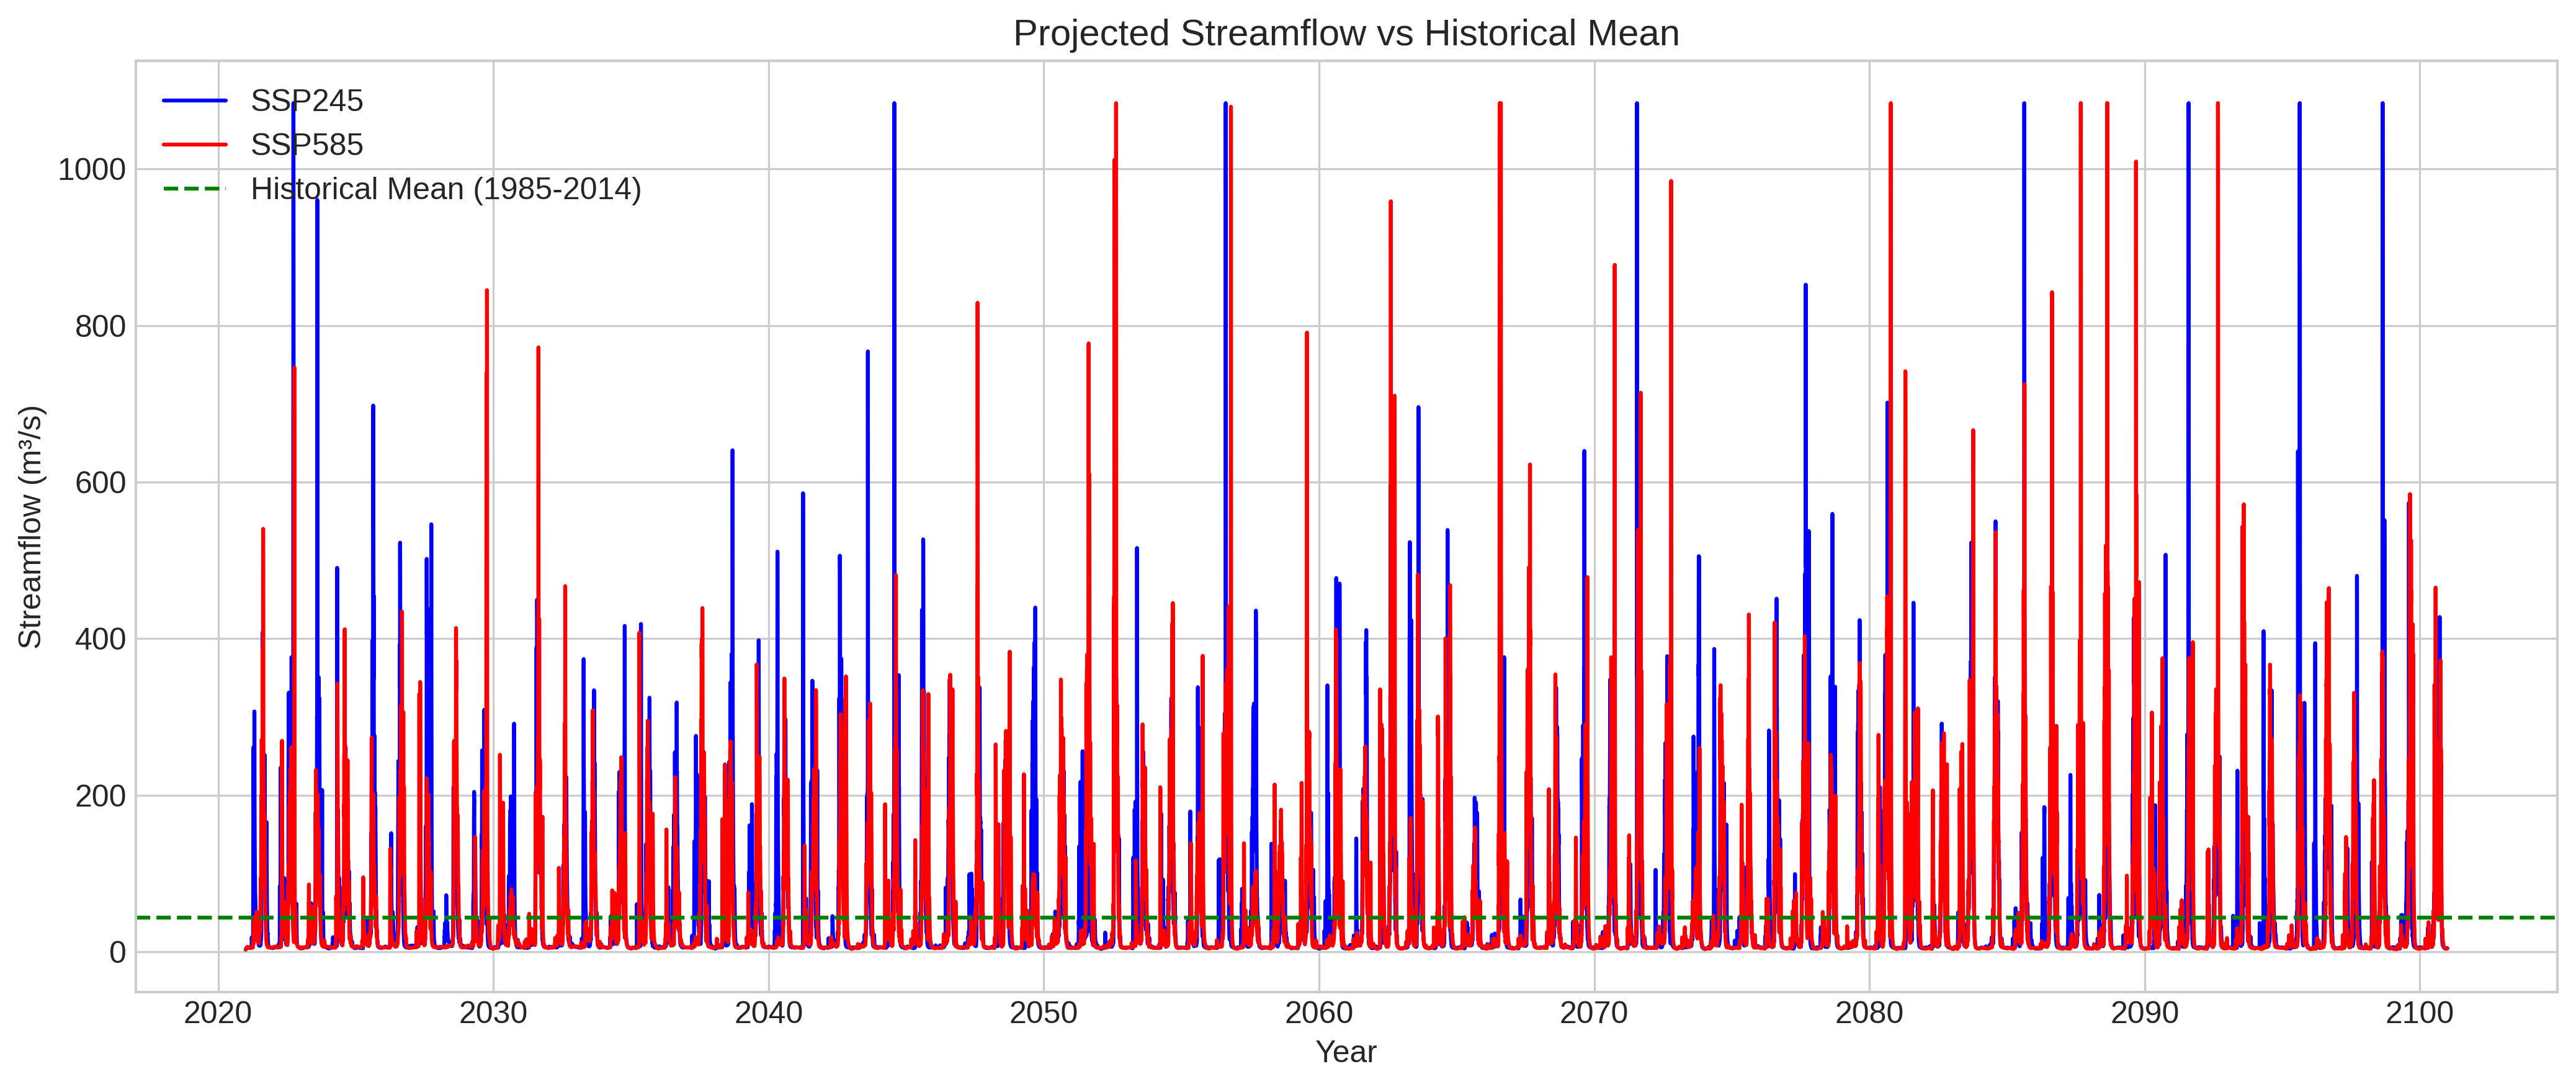

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Time series plots: projected flows vs historical mean ---
historical_mean = df_hist['Streamflow'].mean()

plt.figure(figsize=(14,6))
plt.plot(res_245.index, res_245['Flow'], label='SSP245', color='blue')
plt.plot(res_585.index, res_585['Flow'], label='SSP585', color='red')
plt.axhline(historical_mean, color='green', linestyle='--', label='Historical Mean (1985-2014)')
plt.title('Projected Streamflow vs Historical Mean')
plt.xlabel('Year')
plt.ylabel('Streamflow (m³/s)')
plt.legend()
plt.tight_layout()
plt.show()

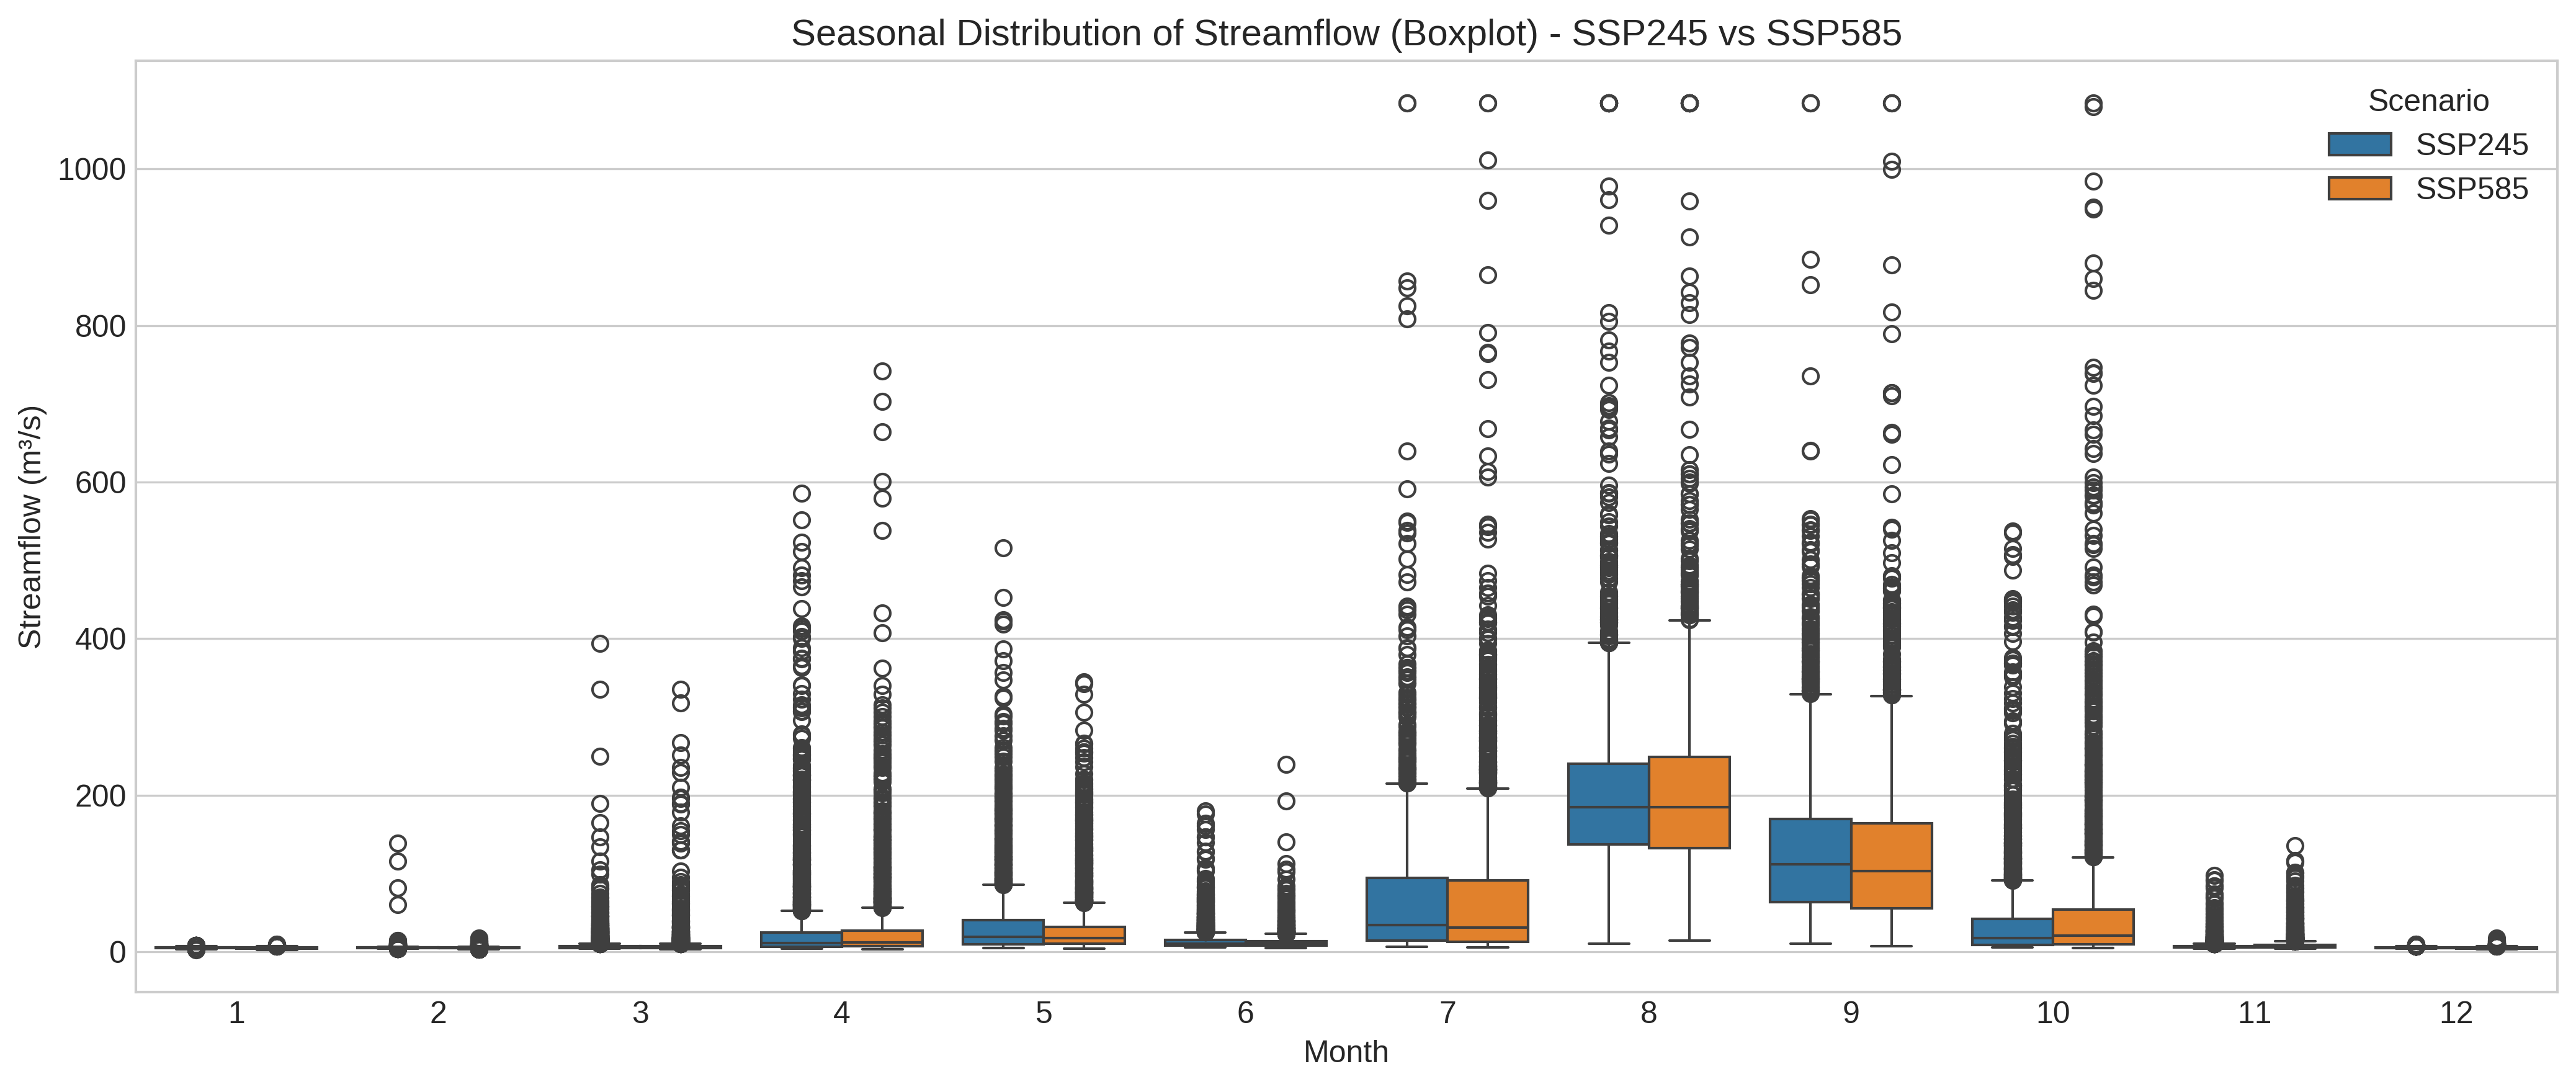

In [27]:
# --- 2. Boxplots of seasonal flows ---
# Add month column
res_245['Month'] = res_245.index.month
res_585['Month'] = res_585.index.month

plt.figure(figsize=(14,6))
sns.boxplot(x='Month', y='Flow', data=pd.concat([res_245.assign(Scenario='SSP245'), res_585.assign(Scenario='SSP585')]),
            hue='Scenario')
plt.title('Seasonal Distribution of Streamflow (Boxplot) - SSP245 vs SSP585')
plt.xlabel('Month')
plt.ylabel('Streamflow (m³/s)')
plt.legend(title='Scenario')
plt.tight_layout()
plt.show()


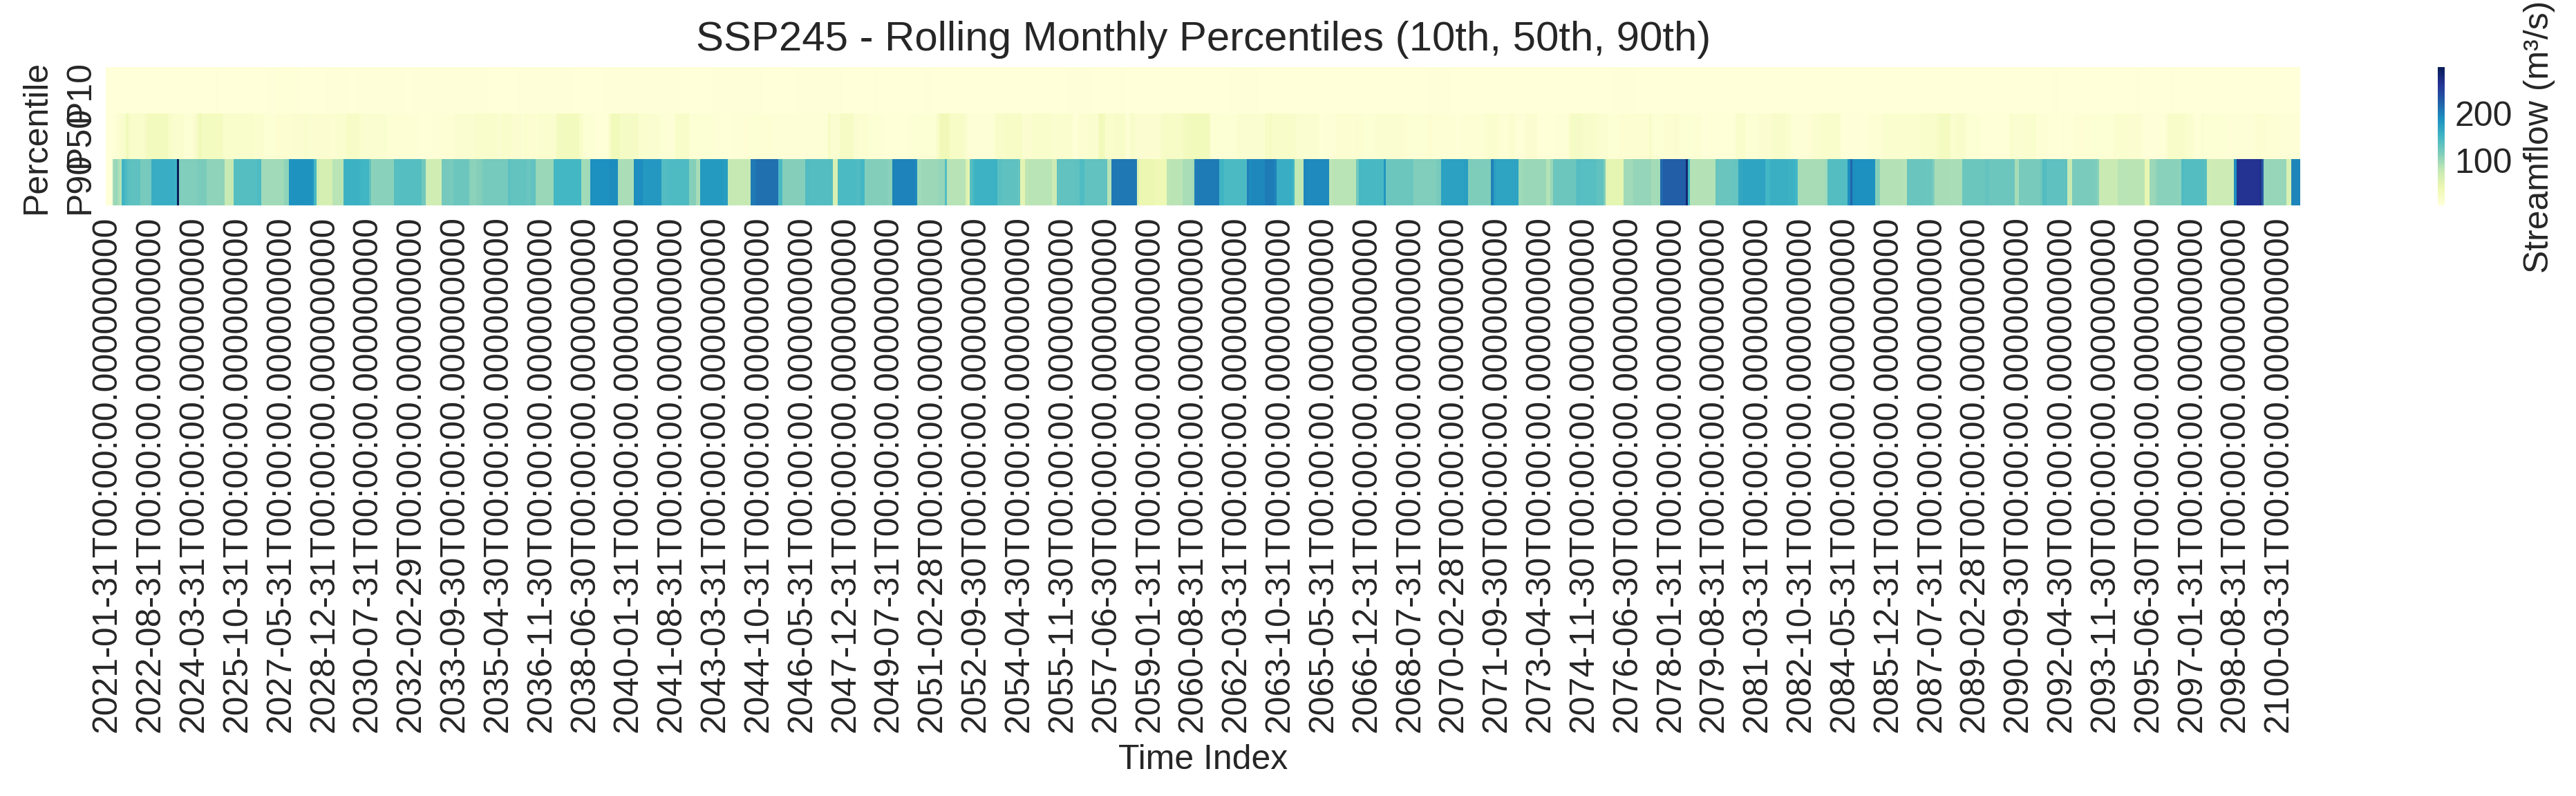

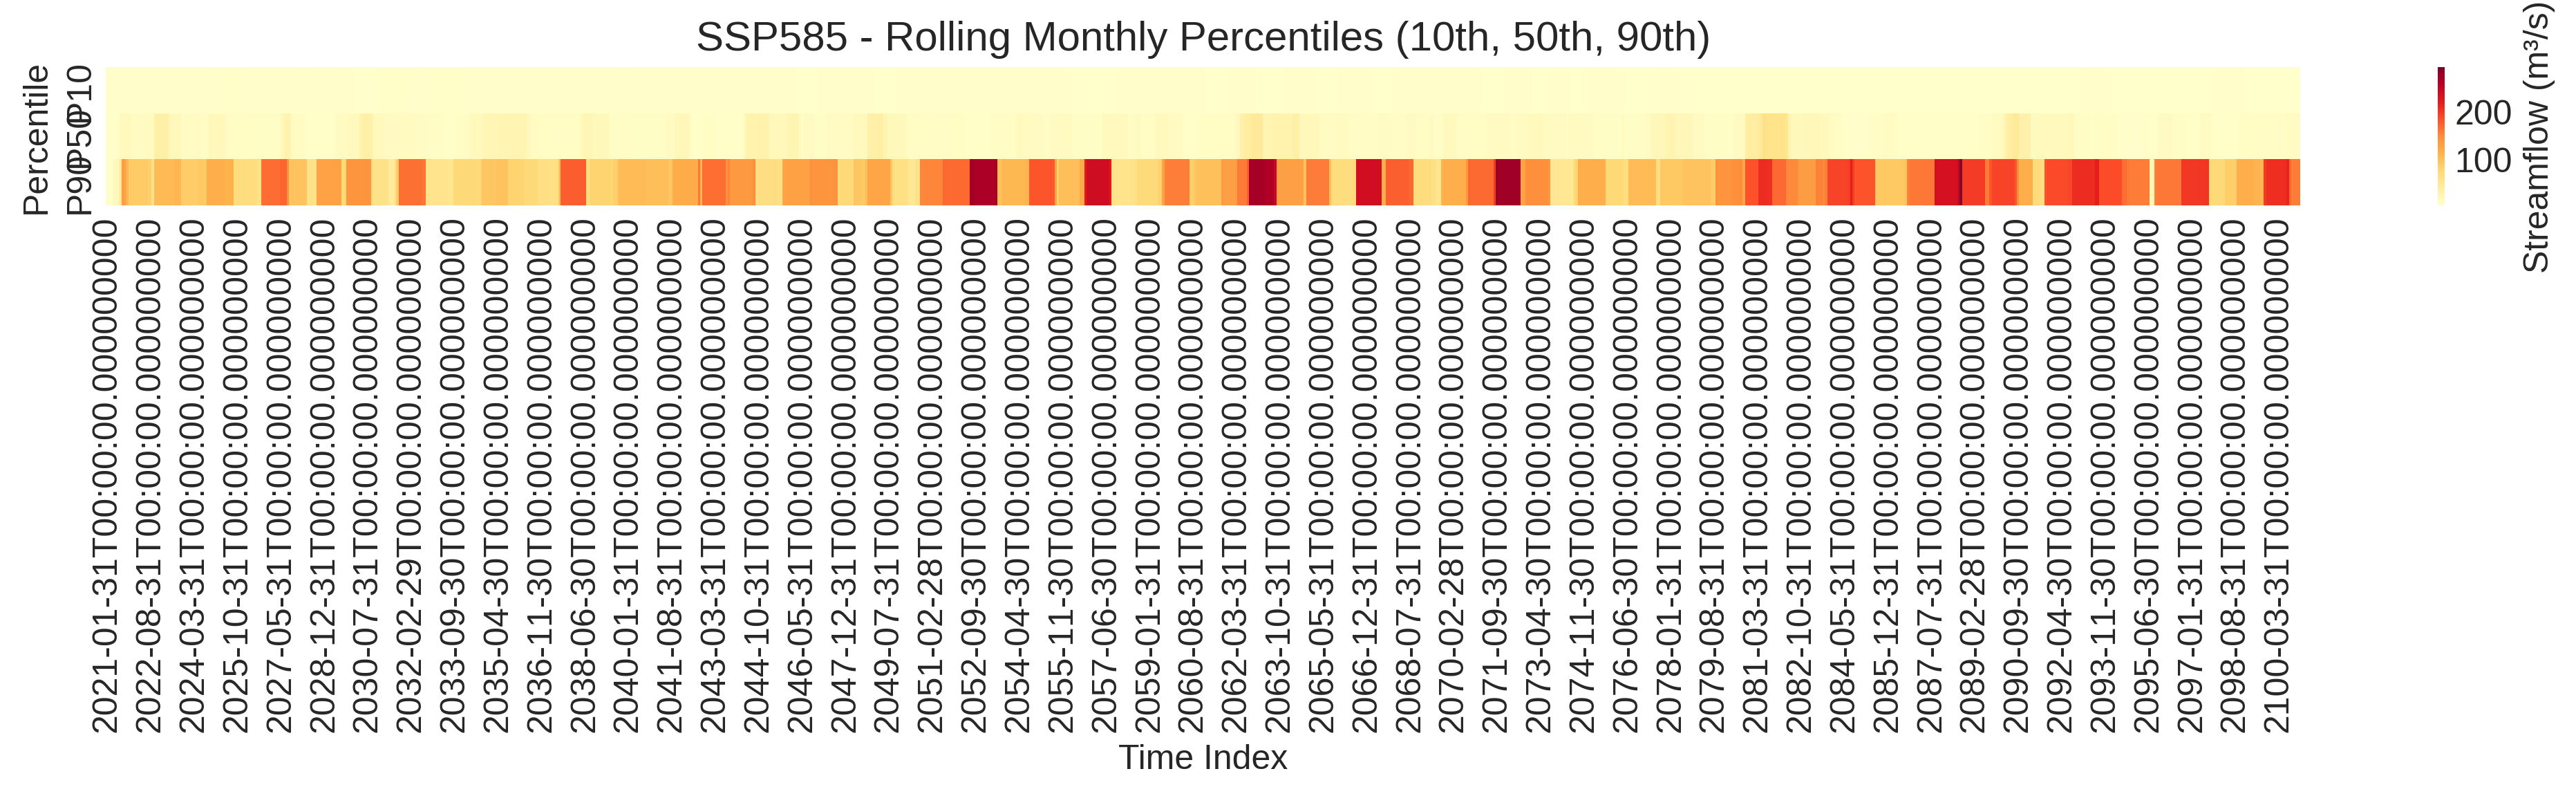

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 3. Heatmaps showing flow percentiles (10th, 50th, 90th) for each scenario ---
def compute_percentiles(df):
    # Resample monthly and compute percentiles
    monthly = df['Flow'].resample('ME').mean() # Changed 'M' to 'ME' for future compatibility

    # Calculate each percentile separately and then combine
    percentiles_list = []
    quantiles_to_compute = [0.1, 0.5, 0.9]
    column_names = ['P10', 'P50', 'P90']

    for q, col_name in zip(quantiles_to_compute, column_names):
        # .quantile(q_val) returns a Series
        q_series = monthly.rolling(window=12, min_periods=1).quantile(q)
        percentiles_list.append(q_series.rename(col_name))

    # Concatenate the Series into a DataFrame
    percentiles = pd.concat(percentiles_list, axis=1) # Removed .unstack() as it's not needed
    percentiles.columns = column_names # Ensure column names are correct
    return percentiles

percentiles_245 = compute_percentiles(res_245)
percentiles_585 = compute_percentiles(res_585)

# Heatmap for SSP245
plt.figure(figsize=(14,4))
sns.heatmap(percentiles_245.T, cmap='YlGnBu', cbar_kws={'label':'Streamflow (m³/s)'})
plt.title('SSP245 - Rolling Monthly Percentiles (10th, 50th, 90th)')
plt.xlabel('Time Index')
plt.ylabel('Percentile')
plt.tight_layout()
plt.show()

# Heatmap for SSP585
plt.figure(figsize=(14,4))
sns.heatmap(percentiles_585.T, cmap='YlOrRd', cbar_kws={'label':'Streamflow (m³/s)'})
plt.title('SSP585 - Rolling Monthly Percentiles (10th, 50th, 90th)')
plt.xlabel('Time Index')
plt.ylabel('Percentile')
plt.tight_layout()
plt.show()